In [22]:
!pip install pyspellchecker

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 6.0 MB/s  0:00:01m 6.1 MB/s eta 0:00:01


In [6]:
from lxml import etree
import cv2
import matplotlib.pyplot as plt

In [7]:
alto_path = 'data/newspapers/0346.xml'

In [8]:
tree = etree.parse(alto_path)
root = tree.getroot()

In [9]:
nsmap = {k or 'alto': v for k, v in root.nsmap.items() if v}
ns = {'a': nsmap.get('alto', root.tag.split('}')[0].strip('{'))}

In [10]:
def xp(node, path):
    return node.xpath(path, namespaces=ns)

def _int_attr(el, name, default=0):
    v = el.get(name)
    return int(float(v)) if v is not None else default

def iter_line_tokens(textline):
    """
    Yield tokens in the order they appear inside the TextLine:
    - <String CONTENT="...">
    - <SP> (space)
    - <HYP CONTENT="-"> (hyphen, sometimes)
    """
    # We read children in-document order.
    for child in textline:
        tag = etree.QName(child).localname
        if tag == "String":
            yield ("STR", child.get("CONTENT", ""))
        elif tag == "SP":
            yield ("SP", " ")
        elif tag == "HYP":
            # Some ALTO uses CONTENT, some not; default to hyphen.
            yield ("HYP", child.get("CONTENT") or "-")

def text_of_line(textline):
    parts = []
    for kind, val in iter_line_tokens(textline):
        parts.append(val)
    # Normalize: collapse repeated spaces if you want
    return "".join(parts).strip()

def line_sort_key(textline):
    # Standard ALTO geometry attributes are VPOS/HPOS (y/x), WIDTH/HEIGHT
    y = _int_attr(textline, "VPOS", 0)
    x = _int_attr(textline, "HPOS", 0)
    return (y, x)

def extract_block_text(textblock, join_with="\n"):
    """
    Extract text for a single <TextBlock>:
    - sorts TextLine by (VPOS, HPOS)
    - joins lines with newline (default) or space
    """
    lines = xp(textblock, "./a:TextLine")
    lines_sorted = sorted(lines, key=line_sort_key)
    # print(lines_sorted)
    out_lines = []
    for tl in lines_sorted:
        s = text_of_line(tl)
        if s:
            out_lines.append(s)

    # Optional: handle end-of-line hyphenation:
    # if a line ends with '-' and next line starts with a letter, merge them.
    merged = []
    i = 0
    while i < len(out_lines):
        cur = out_lines[i]
        if i < len(out_lines) - 1 and cur.endswith("-"):
            nxt = out_lines[i + 1].lstrip()
            if nxt and nxt[0].isalpha():
                merged.append(cur[:-1] + nxt)  # drop hyphen + merge
                i += 2
                continue
        merged.append(cur)
        i += 1

    return join_with.join(merged)

In [11]:
tblock = xp(root, './/a:TextBlock')[0]
lx = float(tblock.get('HPOS')); ly = float(tblock.get('VPOS'))
lw = float(tblock.get('WIDTH')); lh = float(tblock.get('HEIGHT'))

In [12]:
def debug_draw_layout(image_rgb, blocks, hs, vs, gutters=None, path="debug.png"):
    img = image_rgb.copy()
    for b in blocks:
        lx = int(float(b.get('HPOS'))); ly = int(float(b.get('VPOS')))
        lw = int(float(b.get('WIDTH'))); lh = int(float(b.get('HEIGHT')))
        x1 = int(hs * lx)
        y1 = int(vs * ly)
        x2 = int(hs * (lx + lw))
        y2 = int(vs * (ly + lh))
        print(x1, x2, y1, y2)
        # x1,y1,x2,y2 = map(int, [b.block.x_1, b.block.y_1, b.block.x_2, b.block.y_2])
        color = (0,255,0)
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 20)
    if gutters:
        for x in gutters:
            cv2.line(img, (int(x),0), (int(x),img.shape[0]-1), (0,0,255), 1)
    # cv2.imwrite(path, img[..., ::-1])  # RGB->BGR for write
    return img

In [14]:
ip = 'data/newspapers/service-ndnp-prru-batch_prru_ballena_ver01-data-sn90070270-00271761995-1899021301-0346.jpg'
# Load and convert BGR->RGB
image_bgr = cv2.imread(ip)

image = image_bgr[..., ::-1]
# image = deskew_grayscale(image)
h, w = image.shape[:2]



In [28]:
image.shape

(10056, 7552, 3)

In [56]:
40224/10056

4.0

In [15]:
page = xp(root, './/a:Page')[0]
page_h = int(page.get('HEIGHT'))
page_w = int(page.get('WIDTH'))
hs = w/page_w
vs = h/page_h

In [16]:
tline = xp(root, './/a:String')[7]
tline.get('CONTENT')

'DENUNCIADOS-'

In [17]:
r = blocks[8]

NameError: name 'blocks' is not defined

In [18]:
blocks = xp(root, './/a:TextBlock')
lines = xp(blocks[8], './/a:TextLine')
# blocks/

In [ ]:
"'i- j. i x :-D j. t. uiuiaruu m suui uncía contra man" for "dictaron la sentencia contra Juan"
"manmesto" for "manifiesto"
"s dados" for "silados" (italicised)
". .D.cl sumario .y de las" for "Del sumario y de las"
"Y Y para ütian castra." for "para Juan Lastra"


In [19]:
block_text = extract_block_text(blocks[8], join_with="\n")
print(block_text)

tor de los ártículos que venimos
publicando con el título Justicia....
catalana., artículos que han sido
calificados por el Juez de injurias
y calumnias á los Magistrados qúe
'i- j. i x :-D j. t.
uiuiaruu m suui uncía contra man
Lastra.
Injurias y calumnias! Nosotros
nos hemos concretado á la relación
de los hechos y á la reproducción
de los textos legales, que ponen de
manmesto la injusticia y la arbitrariedad que se han cometido.
Si hubiéramos ido á calificar
esos hechos como se merecen, dai .i . i - i .
uo ei sistema español ano aunimpera, á estas horas estaríamos fu-
s dados.
. .D.cl sumario .y de las pruebas del
juicio oral no aparece culpabilidad
Y Y
para ütian castra.
De todos los textos legales que
hemos publicado, se desprende, sin
lugar á dudas, que retirada la acusación por el F iscal, el Tribunal no
puede condenar al procesado
La sentencia, pues, que condena
á Juan Lastra .es manifiestamente
injusta; pues lo que se dá como proüacio no es cierto.
oí lo es- moral no lo es leg

In [117]:
cv2.imwrite('debuf.png', debug_draw_layout(image, [blocks[8]], hs, vs)[..., ::-1])

1631 2721 1248 7206


True

9072 12176 384 1944


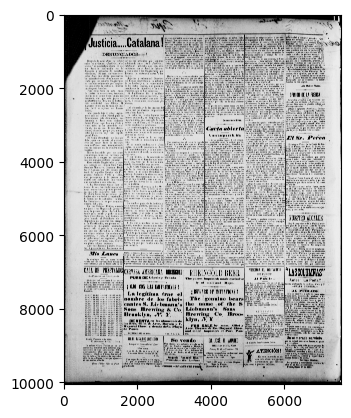

In [24]:
plt.imshow()

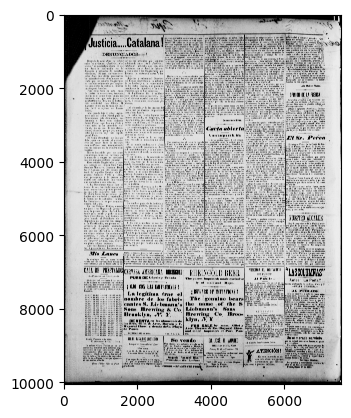

In [17]:
plt.imshow(image)

In [45]:
!pip install wordfreq

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 5.7 MB/s  0:00:10 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [wordfreq]


In [38]:
from symspellpy import SymSpell, Verbosity

In [46]:
from wordfreq import zipf_frequency, top_n_list

words = top_n_list("es", 200_000)

with open("spanish_frequency_dictionary.txt", "w", encoding="utf-8") as f:
    for w in words:
        freq = zipf_frequency(w, "es")
        # SymSpell needs integer counts
        count = int(10 ** freq)
        f.write(f"{w} {count}\n")

In [47]:
symspell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

symspell.load_dictionary(
    "spanish_frequency_dictionary.txt",
    term_index=0,
    count_index=1
)


True

In [32]:
text = "manmesto s dados"
spell = SpellChecker(language="es")

text = "para ütian castra."
tokens = text.split()

corrected = []
for tok in tokens:
    # only try to correct alphabetic tokens
    if tok.isalpha():
        corrected.append(spell.correction(tok))
    else:
        corrected.append(tok)


In [52]:
suggestions = symspell.lookup(
    'manmesto',
    Verbosity.CLOSEST,
    max_edit_distance=2
)

In [55]:
[t.term for t in suggestions]

['mamerto', 'manifesto', 'banesto', 'armesto']

Steps:
Build a gold dataset with LLM as a judge
Fix pipeline